## Part 1: Tutorial

In [3]:
import pandas as pd
dataset= pd.read_csv('pizza.csv')
dataset.head()

,brand,id,mois,prot,fat,ash,sodium,carb,cal
0,A,14069,27.82,21.43,44.87,5.11,1.77,0.77,4.93
1,A,14053,28.49,21.26,43.89,5.34,1.79,1.02,4.84
2,A,14025,28.35,19.99,45.78,5.08,1.63,0.80,4.95
3,A,14016,30.55,20.15,43.13,4.79,1.61,1.38,4.74
4,A,14005,30.49,21.28,41.65,4.82,1.64,1.76,4.67


In [4]:
dataset.corr(numeric_only=True)

,id,mois,prot,fat,ash,sodium,carb,cal
id,1.000000,0.032595,-0.076485,-0.004860,-0.034072,-0.015156,0.014966,-0.021209
mois,0.032595,1.000000,0.360248,-0.171318,0.265556,-0.102279,-0.591802,-0.764441
prot,-0.076485,0.360248,1.000000,0.498002,0.823844,0.429130,-0.853542,0.070258
fat,-0.004860,-0.171318,0.498002,1.000000,0.791634,0.933325,-0.640238,0.764567
ash,-0.034072,0.265556,0.823844,0.791634,1.000000,0.808122,-0.898988,0.326468
sodium,-0.015156,-0.102279,0.429130,0.933325,0.808122,1.000000,-0.620176,0.671958
carb,0.014966,-0.591802,-0.853542,-0.640238,-0.898988,-0.620176,1.000000,-0.023485
cal,-0.021209,-0.764441,0.070258,0.764567,0.326468,0.671958,-0.023485,1.000000


In [5]:
import numpy as np
A= np.array([[3, 1], [1,3]])

l, v= np.linalg.eig(A)
print("Eigenvalues:", l)
print("Eigenvectors:", v)

Eigenvalues: [4.+0.j 2.+0.j]
Eigenvectors: [[ 0.70710678+0.j -0.70710678+0.j]
 [ 0.70710678+0.j  0.70710678+0.j]]


In [8]:
#Dropping the brand name column before standardizing the data
df_num = dataset.drop(["brand", "id"], axis=1)

# Setting the brand name column as the target variable
target = dataset["brand"]

#Scaling the data (Step 1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_num)
scaled_data = scaler.transform(df_num)

#Applying PCA to the scaled data
from sklearn.decomposition import PCA

#Reducing the dimensions to 2 components so that we can have a 2D visualization
pca = PCA(n_components = 2)
pca.fit(scaled_data)
#Applying to our scaled dataset
scaled_data_pca = pca.transform(scaled_data)
#Check the shape of the original dataset and the new dataset
print("The dimensions of the original dataset is: ", scaled_data.shape)
print("The dimensions of the dataset after performing PCA is: ", scaled_data_pca.shape)

The dimensions of the original dataset is:  (300, 7)
The dimensions of the dataset after performing PCA is:  (300, 2)


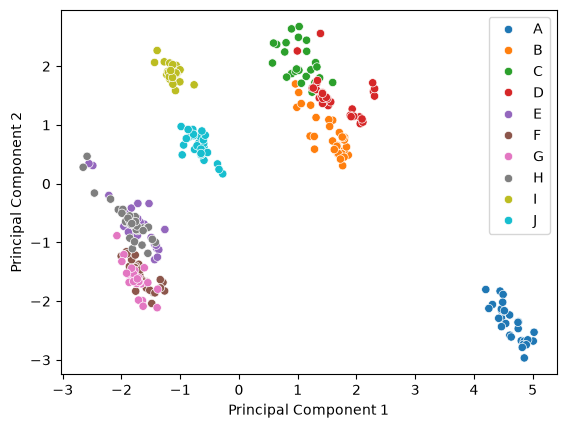

In [11]:
#Plotting the principal components
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=scaled_data_pca[:,0], y=scaled_data_pca[:,1], hue=target)
plt.legend(loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [12]:
import pandas as pd

dataset = pd.read_csv('pizza.csv')

#Dropping the brand name column before standardizing the data
df_num = dataset.drop(["brand", "id"], axis=1)
# Setting the brand name column as the target variable
target = dataset['brand']

#Scaling the data (Step 1)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_num)
scaled_data = scaler.transform(df_num)

#Applying PCA to the scaled data
from sklearn.decomposition import PCA

#Setting the variance to 0.95
pca = PCA(n_components = 0.95)
pca.fit(scaled_data)
#Applying to our scaled dataset
scaled_data_pca = pca.transform(scaled_data)
#Check the shape of the original dataset and the new dataset
print("The dimensions of the original dataset are: ", scaled_data.shape)
print("The dimensions of the dataset after performing PCA is: ", scaled_data_pca.shape)

The dimensions of the original dataset are:  (300, 7)
The dimensions of the dataset after performing PCA is:  (300, 3)


## Part II: Exercises

### (1) Manual PCA

$$
X=\begin{bmatrix}7&7&8&6\\10&2&4&3\\2&7&3&5\\2&5&7&4\\8&5&3&2\end{bmatrix}
$$

Standardize  $z=\dfrac{x-\bar{x}}{s}$

$$
\bar{x}=\begin{bmatrix}5.8&5.2&5&4\end{bmatrix},\qquad s=\begin{bmatrix}3.6332&2.0494&2.3452&1.5811\end{bmatrix}
$$

$$
Z=\begin{bmatrix}0.3303&0.8783&1.2792&1.2649\\1.1560&-1.5614&-0.4264&-0.6325\\-1.0459&0.8783&-0.8528&0.6325\\-1.0459&-0.0976&0.8528&0\\0.6055&-0.0976&-0.8528&-1.2649\end{bmatrix}
$$

(a) Covariance matrix

$$
C=\frac{1}{n-1}Z^TZ=\begin{bmatrix}1&-0.5977&-0.1467&-0.4352\\-0.5977&1&0.2601&0.6944\\-0.1467&0.2601&1&0.6068\\-0.4352&0.6944&0.6068&1\end{bmatrix}
$$

(b) Diagonalization, sort the order and  solve $\det(\lambda I - C)=0$:

$$
\Lambda=\begin{bmatrix}2.4129&0&0&0\\0&0.9624&0&0\\0&0&0.4325&0\\0&0&0&0.1922\end{bmatrix}
$$

$$
V=\begin{bmatrix}-0.4522&0.5586&0.6870&-0.1076\\0.5493&-0.3069&0.5208&-0.5769\\0.3971&0.7382&-0.3974&-0.3734\\0.5798&0.2209&0.3145&0.7184\end{bmatrix}
$$

Proportion of variance

$$
\frac{\lambda_i}{\sum\lambda}=0.6032,\;0.2406,\;0.1081,\;0.0480
$$


(c) Transform

$$
Z\,V_2=Z\begin{bmatrix}-0.4522&0.5586\\0.5493&-0.3069\\0.3971&0.7382\\0.5798&0.2209\end{bmatrix}=\begin{bmatrix}1.5744&1.1387\\-1.9164&0.6705\\0.9835&-1.3437\\0.7580&0.0753\\-1.3994&-0.5408\end{bmatrix}
$$


2. PCA in python

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset = pd.DataFrame(
    {"item": ["item1", "item2", "item3", "item4", "item5"],
     "f1": [7, 10, 2, 2, 8],
     "f2": [7, 2, 7, 5, 5],
     "f3": [8, 4, 3, 7, 3],
     "f4": [6, 3, 5, 4, 2]})

# Dropping the label column before standardizing (like dropping "brand")
df_num = dataset.drop(["item"], axis=1)
target = dataset["item"]
dataset

,item,f1,f2,f3,f4
0,item1,7,7,8,6
1,item2,10,2,4,3
2,item3,2,7,3,5
3,item4,2,5,7,4
4,item5,8,5,3,2


In [15]:

np.set_printoptions(precision=4, suppress=True)

X = df_num.values.astype(float)
n = X.shape[0]

Z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
print("Standardized data Z:\n", Z)

C = Z.T @ Z / (n - 1)
print("\nCovariance matrix C:\n", C)

Standardized data Z:
 [[ 0.3303  0.8783  1.2792  1.2649]
 [ 1.156  -1.5614 -0.4264 -0.6325]
 [-1.0459  0.8783 -0.8528  0.6325]
 [-1.0459 -0.0976  0.8528  0.    ]
 [ 0.6055 -0.0976 -0.8528 -1.2649]]

Covariance matrix C:
 [[ 1.     -0.5977 -0.1467 -0.4352]
 [-0.5977  1.      0.2601  0.6944]
 [-0.1467  0.2601  1.      0.6068]
 [-0.4352  0.6944  0.6068  1.    ]]


In [ ]:
# Eigenvalue and vec , sort 

eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Diagonal eigenvalue matrix:\n", np.diag(eigvals))
print("\nEigenvector matrix (columns = PC1..PC4):\n", eigvecs)

ratios = eigvals / eigvals.sum()

print("\nProportion of variance:", ratios)
print("Cumulative:", np.cumsum(ratios))

Diagonal eigenvalue matrix:
 [[2.4129 0.     0.     0.    ]
 [0.     0.9624 0.     0.    ]
 [0.     0.     0.4325 0.    ]
 [0.     0.     0.     0.1922]]

Eigenvector matrix (columns = PC1..PC4):
 [[-0.4522  0.5586  0.687  -0.1076]
 [ 0.5493 -0.3069  0.5208 -0.5769]
 [ 0.3971  0.7382 -0.3974 -0.3734]
 [ 0.5798  0.2209  0.3145  0.7184]]

Proportion of variance: [0.6032 0.2406 0.1081 0.048 ]
Cumulative: [0.6032 0.8438 0.952  1.    ]


In [17]:
# keep 2 principal components
# set k =2 for later changes
k=2

new_data = Z @ eigvecs[:, :k]
print("Transformed data (Z x V2):\n", new_data)

Transformed data (Z x V2):
 [[ 1.5744  1.1387]
 [-1.9164  0.6705]
 [ 0.9835 -1.3437]
 [ 0.758   0.0753]
 [-1.3994 -0.5408]]


### Scikit-learn PCA


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaler.fit(df_num)
scaled_data = scaler.transform(df_num)

pca = PCA(n_components = 2)
pca.fit(scaled_data)
scaled_data_pca = pca.transform(scaled_data)

print("The dimensions of the original dataset are: ", scaled_data.shape)
print("The dimensions of the dataset after performing PCA is: ", scaled_data_pca.shape)
print("\nsklearn components (rows = PCs):\n", pca.components_)
print("sklearn explained variance ratio:", pca.explained_variance_ratio_)

The dimensions of the original dataset are:  (5, 4)
The dimensions of the dataset after performing PCA is:  (5, 2)

sklearn components (rows = PCs):
 [[-0.4522  0.5493  0.3971  0.5798]
 [ 0.5586 -0.3069  0.7382  0.2209]]
sklearn explained variance ratio: [0.6032 0.2406]


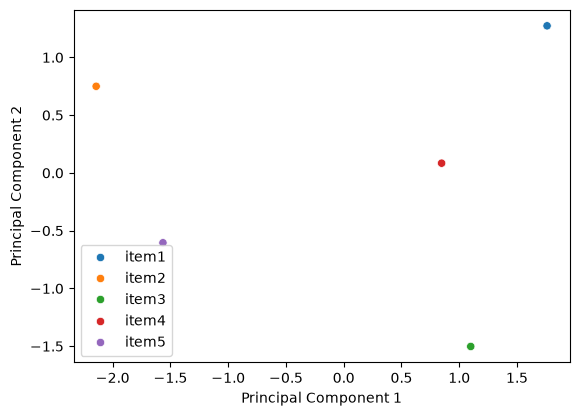

In [19]:
#Plotting the principal components
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=scaled_data_pca[:,0], y=scaled_data_pca[:,1], hue=target)
plt.legend(loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()